# 6CS012 - Worksheet 5
## End-to-End CNN Model for Image Classification (Amazon Fruits)
**Module:** Artificial Intelligence and Machine Learning

---
## Imports & Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from PIL import Image
from sklearn.metrics import classification_report

# Seed for reproducibility
SEED = 123
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


---
## Task 1: Data Understanding and Visualization

### 1.1 — Define Dataset Path

In [18]:
train_dir = '/content/drive/MyDrive/AI&ML/week5/FruitinAmazon/train'
test_dir  = '/content/drive/MyDrive/AI&ML/week5/FruitinAmazon/test'

### 1.2 — Visualize One Image Per Class (Grid with 2 Rows)

Classes found (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


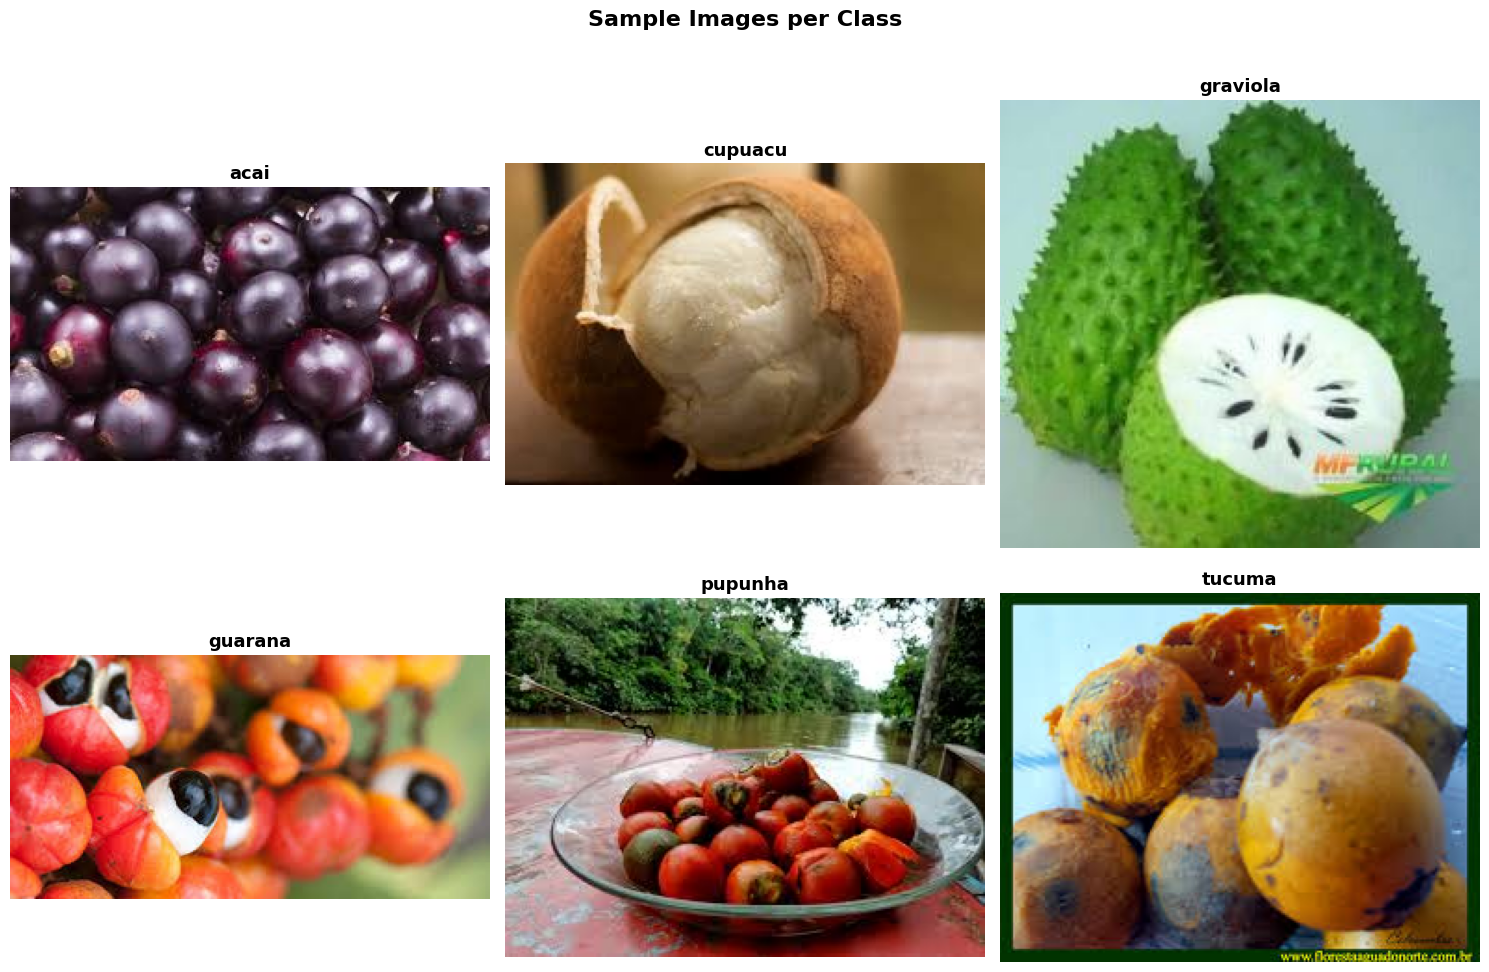


Observation:
- The dataset contains images of 6 Amazon fruit classes.
- Images vary in resolution, background, and lighting conditions.
- Some classes (e.g. guarana) show clustered fruits while others show single specimens.
- Preprocessing (resize + normalise) is essential to standardise inputs for the CNN.



In [4]:
# Get all class directories
class_dirs = sorted(
    [d for d in os.listdir(train_dir)
     if os.path.isdir(os.path.join(train_dir, d))]
)

print(f"Classes found ({len(class_dirs)}): {class_dirs}")

# Pick one random image per class
sample_images = []
sample_labels = []

for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    images   = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if images:
        chosen = random.choice(images)
        sample_images.append(os.path.join(cls_path, chosen))
        sample_labels.append(cls)

# Display in a 2-row grid
n_images = len(sample_images)
cols     = (n_images + 1) // 2      # Ceiling division → 2 rows
rows     = 2

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = axes.flatten()

for i, (img_path, label) in enumerate(zip(sample_images, sample_labels)):
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(label, fontsize=13, fontweight='bold')
    axes[i].axis('off')

# Hide any unused subplots
for j in range(n_images, len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Images per Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("""
Observation:
- The dataset contains images of 6 Amazon fruit classes.
- Images vary in resolution, background, and lighting conditions.
- Some classes (e.g. guarana) show clustered fruits while others show single specimens.
- Preprocessing (resize + normalise) is essential to standardise inputs for the CNN.
""")

### 1.3 — Check for Corrupted Images

In [5]:
corrupted = []

for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    for fname in os.listdir(cls_path):
        img_path = os.path.join(cls_path, fname)
        try:
            with Image.open(img_path) as img:
                img.verify()          # Verifies the file integrity
        except (IOError, SyntaxError):
            print(f"Removed corrupted image: {img_path}")
            os.remove(img_path)
            corrupted.append(img_path)

if not corrupted:
    print("No Corrupted Images Found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted)}")

No Corrupted Images Found.


---
## Task 2: Loading and Preprocessing Image Data

In [8]:
# Hyper-parameters
IMG_HEIGHT       = 128
IMG_WIDTH        = 128
BATCH_SIZE       = 32
VALIDATION_SPLIT = 0.2   # 80% train | 20% validation

# Normalisation layer  (pixel values [0, 255] → [0, 1])
rescale = tf.keras.layers.Rescaling(1.0 / 255)

# ── Training dataset ──────────────────────────────────────────────────────────
train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (IMG_HEIGHT, IMG_WIDTH),
    interpolation    = 'nearest',
    batch_size       = BATCH_SIZE,
    shuffle          = True,
    validation_split = VALIDATION_SPLIT,
    subset           = 'training',
    seed             = SEED
)
train_ds = train_ds_raw.map(lambda x, y: (rescale(x), y))

# ── Validation dataset ────────────────────────────────────────────────────────
val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (IMG_HEIGHT, IMG_WIDTH),
    interpolation    = 'nearest',
    batch_size       = BATCH_SIZE,
    shuffle          = False,
    validation_split = VALIDATION_SPLIT,
    subset           = 'validation',
    seed             = SEED
)
val_ds = val_ds_raw.map(lambda x, y: (rescale(x), y))

# ── Test dataset ──────────────────────────────────────────────────────────────
test_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels        = 'inferred',
    label_mode    = 'int',
    image_size    = (IMG_HEIGHT, IMG_WIDTH),
    interpolation = 'nearest',
    batch_size    = BATCH_SIZE,
    shuffle       = False,
    seed          = SEED
)
test_ds = test_ds_raw.map(lambda x, y: (rescale(x), y))

# Class names inferred from directory structure
class_names = train_ds_raw.class_names
num_classes = len(class_names)
print("Class names :", class_names)
print("Num classes :", num_classes)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num classes : 6


---
## Task 3: Build the CNN Model

In [9]:
model = keras.Sequential([

    # ── Convolutional Block 1 ─────────────────────────────────────────────────
    layers.Conv2D(
        filters     = 32,
        kernel_size = (3, 3),
        padding     = 'same',
        strides     = 1,
        activation  = 'relu',
        input_shape = (IMG_HEIGHT, IMG_WIDTH, 3),
        name        = 'conv2d_1'
    ),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2, name='maxpool_1'),

    # ── Convolutional Block 2 ─────────────────────────────────────────────────
    layers.Conv2D(
        filters     = 32,
        kernel_size = (3, 3),
        padding     = 'same',
        strides     = 1,
        activation  = 'relu',
        name        = 'conv2d_2'
    ),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2, name='maxpool_2'),

    # ── Fully Connected Network ───────────────────────────────────────────────
    layers.Flatten(name='flatten'),

    layers.Dense(64,  activation='relu', name='dense_64'),
    layers.Dense(128, activation='relu', name='dense_128'),

    # ── Output Layer ─────────────────────────────────────────────────────────
    layers.Dense(num_classes, activation='softmax', name='output')
], name='CNN_Fruit_Classifier')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Fruit_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

---
## Task 4: Compile the Model

In [10]:
model.compile(
    optimizer = 'adam',
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


---
## Task 4 (cont.): Train the Model

In [11]:
EPOCHS     = 250
BATCH_SIZE = 16

# ── Callbacks ─────────────────────────────────────────────────────────────────
checkpoint_cb = ModelCheckpoint(
    filepath        = 'best_model.h5',
    monitor         = 'val_accuracy',
    save_best_only  = True,
    mode            = 'max',
    verbose         = 1
)

early_stop_cb = EarlyStopping(
    monitor              = 'val_loss',
    patience             = 20,           # Stop if no improvement for 20 epochs
    restore_best_weights = True,
    verbose              = 1
)

# ── Train ─────────────────────────────────────────────────────────────────────
history = model.fit(
    train_ds,
    epochs          = EPOCHS,
    validation_data = val_ds,
    callbacks       = [checkpoint_cb, early_stop_cb]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.1892 - loss: 2.1477
Epoch 1: val_accuracy improved from None to 0.16667, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 417ms/step - accuracy: 0.2083 - loss: 2.2911 - val_accuracy: 0.1667 - val_loss: 1.7599
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.2031 - loss: 1.8197
Epoch 2: val_accuracy did not improve from 0.16667
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 310ms/step - accuracy: 0.2500 - loss: 1.7945 - val_accuracy: 0.1111 - val_loss: 1.9740
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.3241 - loss: 1.6390
Epoch 3: val_accuracy improved from 0.16667 to 0.72222, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 340ms/step - accuracy: 0.3472 - loss: 1.6057 - val_accuracy: 0.7222 - val_loss: 1.3233
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.4288 - loss: 1.4752
Epoch 4: val_accuracy improved from 0.72222 to 0.83333, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 343ms/step - accuracy: 0.4583 - loss: 1.4590 - val_accuracy: 0.8333 - val_loss: 1.0581
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.4253 - loss: 1.3221
Epoch 5: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step - accuracy: 0.4167 - loss: 1.2948 - val_accuracy: 0.7778 - val_loss: 0.9345
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.5758 - loss: 1.1300
Epoch 6: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 313ms/step - accuracy: 0.5556 - loss: 1.1847 - val_accuracy: 0.6667 - val_loss: 0.8916
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.6852 - loss: 0.9221
Epoch 7: val_accuracy improved from 0.83333 to 0.94444, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 323ms/step - accuracy: 0.6806 - loss: 0.9392 - val_accuracy: 0.9444 - val_loss: 0.4488
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.7483 - loss: 0.8449
Epoch 8: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 324ms/step - accuracy: 0.7917 - loss: 0.7869 - val_accuracy: 0.7222 - val_loss: 0.7821
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.8657 - loss: 0.5805
Epoch 9: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 564ms/step - accuracy: 0.8472 - loss: 0.5891 - val_accuracy: 0.9444 - val_loss: 0.3163
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.9097 - loss: 0.4639
Epoch 10: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 311ms/step - accuracy: 0.9167 - loss: 0.4419 - val_accuracy: 0.6667 - val_loss: 0.6020
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.8993 - loss: 0.

### Training & Validation — Loss and Accuracy Plots

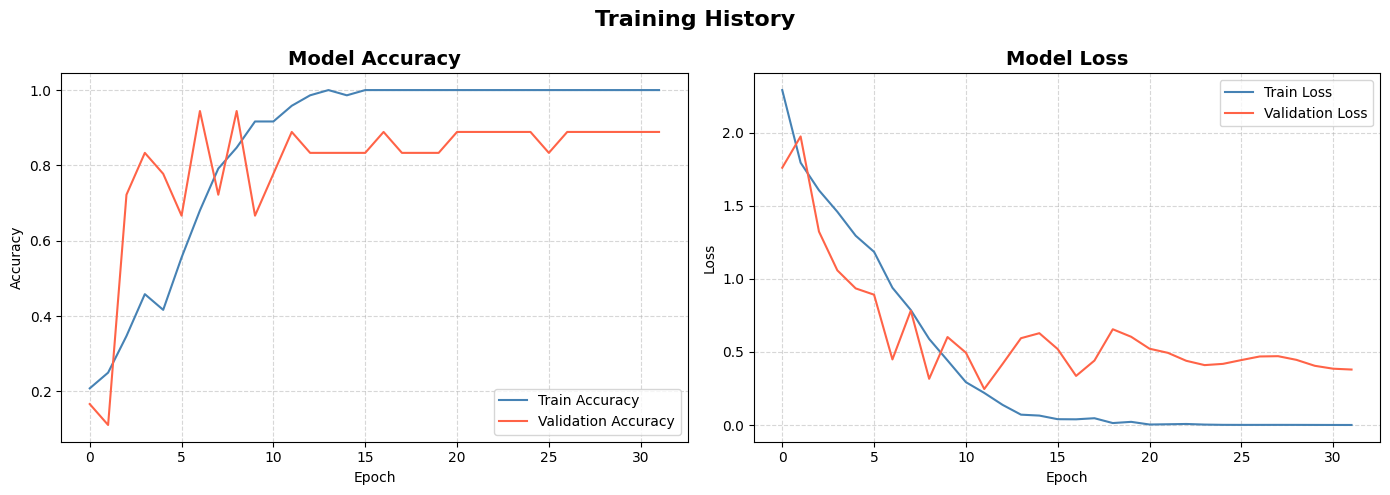

Plot saved as training_history.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy ──
axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='tomato')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# ── Loss ──
axes[1].plot(history.history['loss'],     label='Train Loss',      color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='tomato')
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as training_history.png")

---
## Task 5: Evaluate the Model

In [13]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.6000 - loss: 1.0215

Test Loss     : 1.0215
Test Accuracy : 0.6000


---
## Task 6: Save and Load the Model

In [15]:
# ── Save ──────────────────────────────────────────────────────────────────────
# Saving to a specific Drive path
save_path = '/content/drive/MyDrive/AI&ML/week5/cnn_fruit_classifier.h5'
model.save(save_path)
print(f"Model saved to {save_path}")

# ── Load ──────────────────────────────────────────────────────────────────────
# Using the SAME path to load the model
loaded_model = keras.models.load_model(save_path)
print("Model loaded successfully.")

# ── Re-evaluate loaded model ──────────────────────────────────────────────────
reloaded_loss, reloaded_acc = loaded_model.evaluate(test_ds, verbose=1)
print(f"\nLoaded Model — Test Loss     : {reloaded_loss:.4f}")
print(f"Loaded Model — Test Accuracy : {reloaded_acc:.4f}")

Model saved to /content/drive/MyDrive/AI&ML/week5/cnn_fruit_classifier.h5
Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.6000 - loss: 1.0215

Loaded Model — Test Loss     : 1.0215
Loaded Model — Test Accuracy : 0.6000


---
## Task 7: Predictions and Classification Report

In [16]:
# ── Collect true labels and predictions ───────────────────────────────────────
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ── Classification Report ────────────────────────────────────────────────────
print("Classification Report")
print("=" * 55)
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report
              precision    recall  f1-score   support

        acai       0.57      0.80      0.67         5
     cupuacu       0.38      0.60      0.46         5
    graviola       0.80      0.80      0.80         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.62      1.00      0.77         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.60        30
   macro avg       0.56      0.60      0.54        30
weighted avg       0.56      0.60      0.54        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


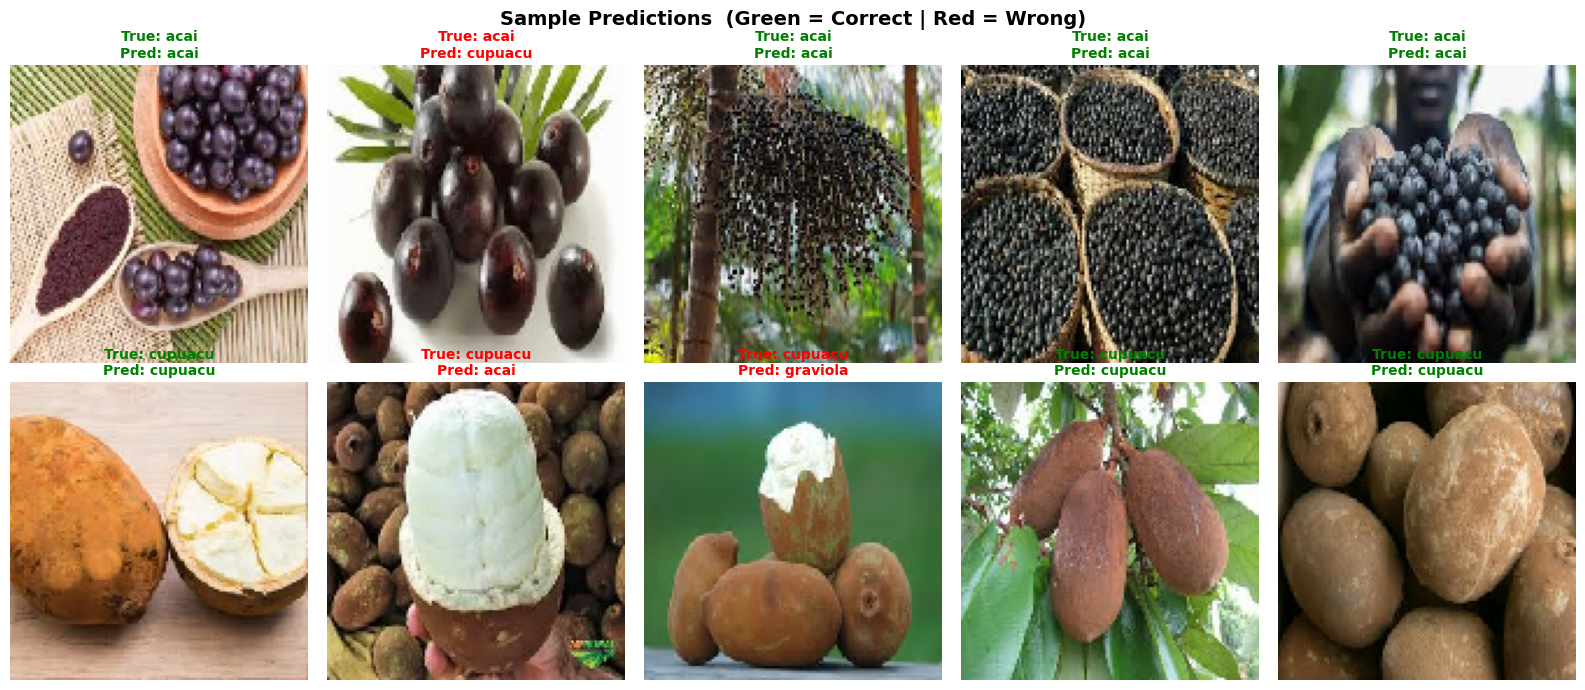

Predictions plot saved as sample_predictions.png


In [17]:
# ── Visualise a few predictions ───────────────────────────────────────────────
sample_images_batch, sample_labels_batch = next(iter(test_ds))
sample_preds = loaded_model.predict(sample_images_batch, verbose=0)
sample_pred_labels = np.argmax(sample_preds, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for i in range(min(10, len(sample_images_batch))):
    axes[i].imshow(sample_images_batch[i].numpy())
    true_label = class_names[sample_labels_batch[i]]
    pred_label = class_names[sample_pred_labels[i]]
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(
        f"True: {true_label}\nPred: {pred_label}",
        color=color, fontsize=10, fontweight='bold'
    )
    axes[i].axis('off')

plt.suptitle('Sample Predictions  (Green = Correct | Red = Wrong)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Predictions plot saved as sample_predictions.png")